## 1. Imports and Data Loaders

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import requests
from io import BytesIO


# 2. Set device

In [20]:
# Fix: Use double underscores __version__
print("Torch Version:", torch.__version__) 
print("GPU Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Final training will be done on: {device}")

Torch Version: 2.10.0+cu128
GPU Available: True
Final training will be done on: cuda


## 3. Basic Transform

In [21]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## 4. Load Datasets

In [22]:
train_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=transform)
val_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 5. Visualize some images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024..1.7502832].


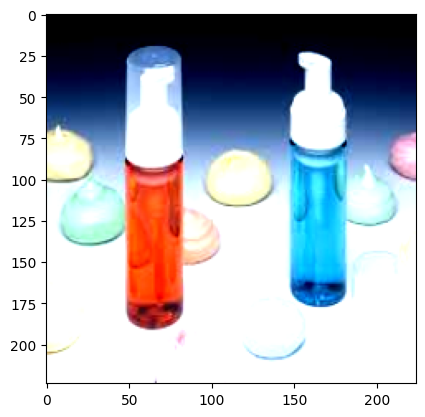

Label: recyclable


In [23]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(images[0])
print(f"Label: {train_dataset.classes[labels[0]]}")

## 5.1. Class Distribution of the Training Dataset

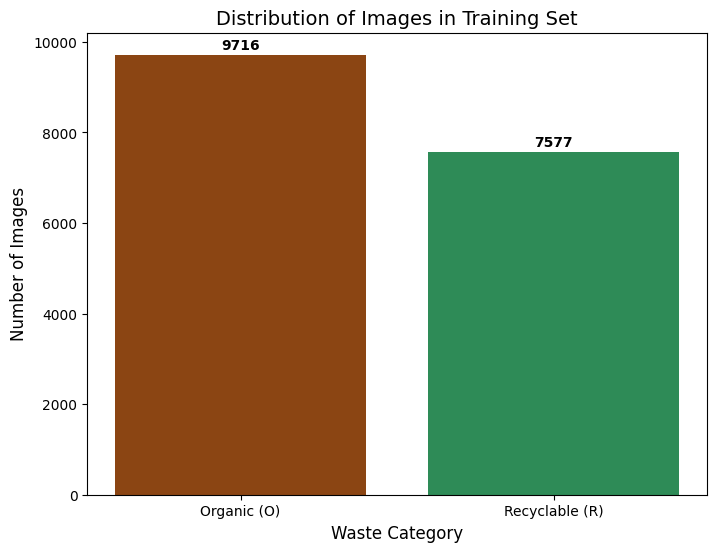

Total organic images: 9716
Total recyclable images: 7577


In [24]:
# 1. Get class names and targets
classes = train_dataset.classes  # ['O', 'R']
targets = np.array(train_dataset.targets)

# 2. Count images in each class
# This counts how many 0s (Organic) and 1s (Recyclable) are in the targets list
counts = [np.sum(targets == i) for i in range(len(classes))]

# 3. Create the Bar Graph
plt.figure(figsize=(8, 6))
colors = ['#8B4513', '#2E8B57'] # Brown for Organic, SeaGreen for Recyclable
bars = plt.bar(classes, counts, color=colors)

# 4. Add the actual numbers on top of the bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontweight='bold')

# 5. Labels and Title
plt.xlabel('Waste Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images in Training Set', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Organic (O)', 'Recyclable (R)'])
plt.show()

# Print the exact numbers for your report
for i, class_name in enumerate(classes):
    print(f"Total {class_name} images: {counts[i]}")

# 6. Baseline Model Definition & Training

In [25]:
# BASELINE MODEL DEFINITION

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # Feature Extraction Layers (Convolutional)
        self.conv_layers = nn.Sequential(
            # Layer 1: Input 3 channels (RGB) -> Output 16 filters
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduces size to 112x112
            
            # Layer 2: 16 -> 32 filters
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Reduces size to 56x56
            
            # Layer 3: 32 -> 64 filters
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # Reduces size to 28x28
        )
        
        # Classification Layers (Fully Connected)
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Output 2 classes: Organic and Recyclable
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x
        
model = BaselineCNN().to(device)

## 6.1. Loss Function and Optimizer

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5 # increase this to 10 or 15 later

## 6.2. TRAINING & VALIDATION LOOP

In [27]:
# 1. Initialize variables for tracking the best model
best_val_acc = 0.0
model_save_path = 'baseline_waste_model.pth'

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print(f"Starting Training on {device}...\n")

for epoch in range(num_epochs):
    # --- Part A: Training ---
    model.train()
    train_running_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_train_acc = 100 * train_correct / train_total

    # --- Part B: Validation ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_running_loss / len(val_loader)
    
    # FIX: Use the correct variable names from above
    epoch_val_acc = 100 * val_correct / val_total 

    # --- Part C: SAVE BEST MODEL LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"--> Epoch {epoch+1}: New Best Val Acc ({best_val_acc:.2f}%)! Model Saved.")

    # Save metrics to history dictionary
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  [TRAIN] Loss: {epoch_train_loss:.4f}, Accuracy: {epoch_train_acc:.2f}%")
    print(f"  [VAL]   Loss: {epoch_val_loss:.4f}, Accuracy: {epoch_val_acc:.2f}%")
    print("-" * 45)

print(f"Training Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

# Load the best weights back for final use
model.load_state_dict(torch.load(model_save_path))

Starting Training on cuda...

--> Epoch 1: New Best Val Acc (85.37%)! Model Saved.
Epoch [1/5]
  [TRAIN] Loss: 0.4110, Accuracy: 82.34%
  [VAL]   Loss: 0.3576, Accuracy: 85.37%
---------------------------------------------
Epoch [2/5]
  [TRAIN] Loss: 0.3319, Accuracy: 86.60%
  [VAL]   Loss: 0.3535, Accuracy: 85.21%
---------------------------------------------
--> Epoch 3: New Best Val Acc (86.72%)! Model Saved.
Epoch [3/5]
  [TRAIN] Loss: 0.2889, Accuracy: 88.46%
  [VAL]   Loss: 0.3250, Accuracy: 86.72%
---------------------------------------------
Epoch [4/5]
  [TRAIN] Loss: 0.2327, Accuracy: 90.64%
  [VAL]   Loss: 0.3604, Accuracy: 85.43%
---------------------------------------------
Epoch [5/5]
  [TRAIN] Loss: 0.1693, Accuracy: 93.28%
  [VAL]   Loss: 0.4243, Accuracy: 86.07%
---------------------------------------------
Training Complete! Best Validation Accuracy: 86.72%


<All keys matched successfully>

## 6.3. Final Test Accuracy

In [31]:
#Val accuracy 
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"Final Test Accuracy: {100 * test_correct / test_total:.2f}%")

Final Test Accuracy: 87.94%


## 6.4. Plotting Accuracy and Loss Curves

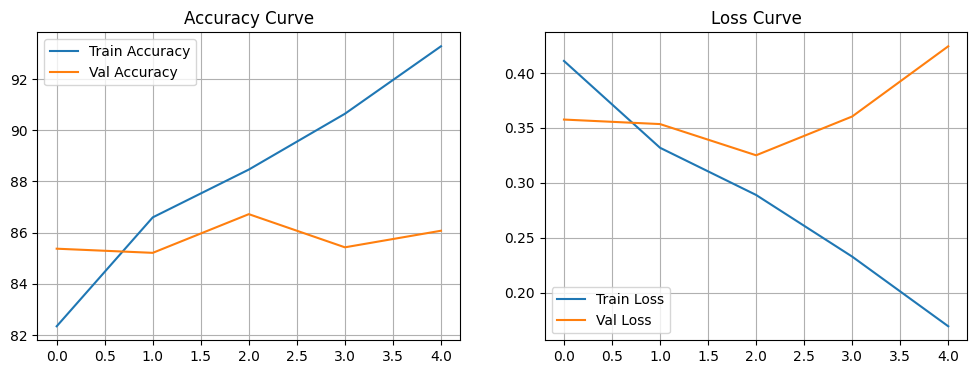

In [32]:
# Create a figure with two subplots
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curve'); plt.legend(); plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve'); plt.legend(); plt.grid(True)

plt.show()

## 6.5. Confusion Matrix & Classification Report


Classification Report:
              precision    recall  f1-score   support

     Organic       0.87      0.92      0.90      2082
  Recyclable       0.89      0.82      0.86      1625

    accuracy                           0.88      3707
   macro avg       0.88      0.87      0.88      3707
weighted avg       0.88      0.88      0.88      3707



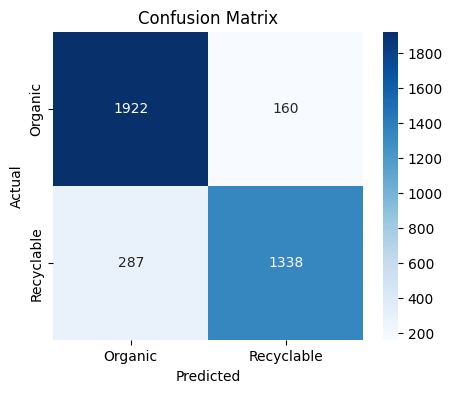

In [33]:
# 1. Get predictions
y_true, y_pred = [], []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 2. Print Text Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable']))

# 3. Plot Heatmap (Confusion Matrix)
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Organic', 'Recyclable'], 
            yticklabels=['Organic', 'Recyclable'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

## 6.5. Predict the base image class

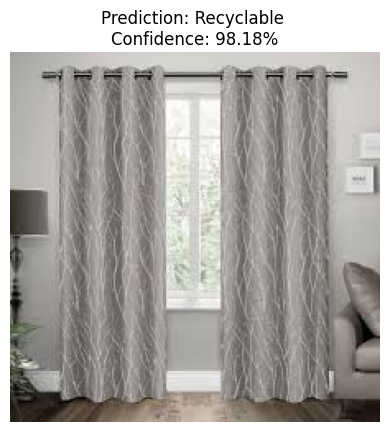

In [34]:
def predict_base_image(image_path, model):
    # 1. Define class names (Matches the folder names)
    # Organic usually corresponds to label 0, Recyclable to label 1
    classes = ['Organic', 'Recyclable']
    
    # 2. Load and preprocess the image
    img = Image.open(image_path).convert('RGB')
    
    # Use the same 'transform' you defined at the beginning of your notebook
    input_tensor = transform(img).unsqueeze(0).to(device) 
    
    # 3. Set model to evaluation mode
    model.eval()
    
    # 4. Perform Inference
    with torch.no_grad():
        output = model(input_tensor)
        # Apply softmax to get probabilities
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    # 5. Display the result
    plt.imshow(img)
    plt.axis('off')
    predicted_class = classes[predicted.item()]
    plt.title(f"Prediction: {predicted_class} \nConfidence: {confidence.item()*100:.2f}%")
    plt.show()


# Pick an image from your test folder to verify
test_img_path = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/recyclable/recyclable_000019_photo.jpg' # Update this path!

predict_base_image(test_img_path, model)

# 7. Improved Data Augumentation 

In [35]:
#Improved Transforms
improved_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset_improved = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=improved_train_transform)
val_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=standard_transform)
test_dataset = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=standard_transform)

# Loaders
train_loader_improved = DataLoader(train_dataset_improved, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Improved Data Loaders Ready.")

Improved Data Loaders Ready.


## 7.1. Improved CNN Architecture

In [36]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),  
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 256), 
            nn.ReLU(),
            nn.Dropout(0.5),             
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

# 3. CONFIGURATION

model_improved = ImprovedCNN().to(device)


## 7.2. Setup with Hyperparameter Tuning

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_improved.parameters(), lr=0.0005) 
num_epochs = 15

## 7.3. Training and Visualization

Starting Improved CNN Training on cuda...
Epoch [1/15] Train Loss: 0.5981 | Val Acc: 83.43% <-- NEW BEST! Model Saved.
Epoch [2/15] Train Loss: 0.4297 | Val Acc: 84.40% <-- NEW BEST! Model Saved.
Epoch [3/15] Train Loss: 0.4203 | Val Acc: 84.72% <-- NEW BEST! Model Saved.
Epoch [4/15] Train Loss: 0.4112 | Val Acc: 84.43%
Epoch [5/15] Train Loss: 0.4094 | Val Acc: 85.29% <-- NEW BEST! Model Saved.
Epoch [6/15] Train Loss: 0.3967 | Val Acc: 85.40% <-- NEW BEST! Model Saved.
Epoch [7/15] Train Loss: 0.3908 | Val Acc: 84.83%
Epoch [8/15] Train Loss: 0.3800 | Val Acc: 85.07%
Epoch [9/15] Train Loss: 0.3757 | Val Acc: 86.07% <-- NEW BEST! Model Saved.
Epoch [10/15] Train Loss: 0.3745 | Val Acc: 85.88%
Epoch [11/15] Train Loss: 0.3679 | Val Acc: 85.56%
Epoch [12/15] Train Loss: 0.3586 | Val Acc: 84.94%
Epoch [13/15] Train Loss: 0.3568 | Val Acc: 86.91% <-- NEW BEST! Model Saved.
Epoch [14/15] Train Loss: 0.3517 | Val Acc: 87.53% <-- NEW BEST! Model Saved.
Epoch [15/15] Train Loss: 0.3444 | Va

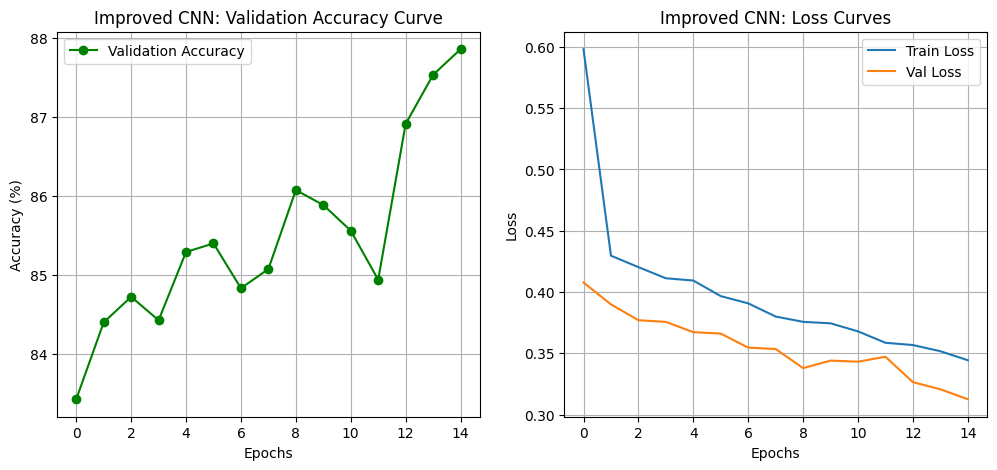

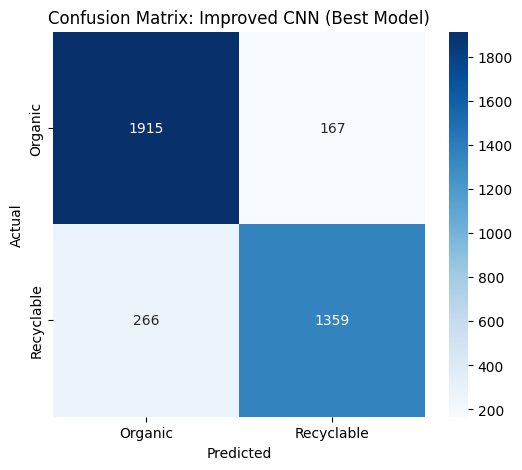


Classification Report (Improved CNN):
              precision    recall  f1-score   support

     Organic       0.88      0.92      0.90      2082
  Recyclable       0.89      0.84      0.86      1625

    accuracy                           0.88      3707
   macro avg       0.88      0.88      0.88      3707
weighted avg       0.88      0.88      0.88      3707


Final Test Accuracy Score using Best Model: 88.32%


In [38]:
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0  # Keep track of the best accuracy
model_path = 'improved_waste_model.pth'

print(f"Starting Improved CNN Training on {device}...")

for epoch in range(num_epochs):
    # --- Training Phase ---
    model_improved.train()
    running_train_loss = 0.0
    for images, labels in train_loader_improved:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_improved(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    
    # --- Validation Phase ---
    model_improved.eval()
    running_val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_improved(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate metrics
    epoch_train_loss = running_train_loss / len(train_loader_improved)
    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = 100 * correct / total

    # Save metrics to lists for plotting
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # --- BEST MODEL SAVING LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        # Save the model weights because this is the best version found so far
        torch.save(model_improved.state_dict(), model_path)
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% <-- NEW BEST! Model Saved.")
    else:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print(f"\nTraining Complete! Best Validation Accuracy achieved: {best_val_acc:.2f}%")

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(val_accuracies, label="Validation Accuracy", color='green', marker='o')
plt.title("Improved CNN: Validation Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Improved CNN: Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


# FINAL EVALUATION: CONFUSION MATRIX & REPORT


# Load the BEST weights back into the model for final testing
model_improved.load_state_dict(torch.load(model_path))
model_improved.eval()

all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_improved(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Organic', 'Recyclable'], 
            yticklabels=['Organic', 'Recyclable'])
plt.title("Confusion Matrix: Improved CNN (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Final Metrics Report
print("\nClassification Report (Improved CNN):")
print(classification_report(all_labels, all_preds, target_names=['Organic', 'Recyclable']))

# Calculate Final Test Accuracy
final_acc = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nFinal Test Accuracy Score using Best Model: {final_acc:.2f}%")

## 7.4. Predicting the image classification

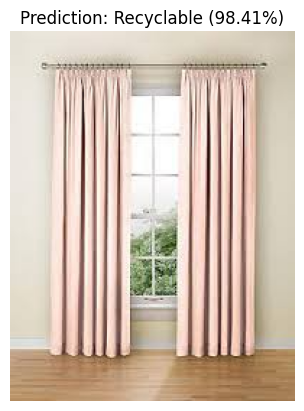

'Recyclable'

In [39]:
def predict_waste(image_path, model):
    # 1. Define the class names based on your dataset folders
    class_names = ['Organic', 'Recyclable']
    
    # 2. Load the image
    img = Image.open(image_path).convert('RGB')
    
    # 3. Apply the standard transforms (same as used in validation/test)
    # We use the 'standard_transform'  defined earlier
    img_tensor = standard_transform(img).unsqueeze(0).to(device)
    
    # 4. Set model to evaluation mode
    model.eval()
    
    # 5. Perform prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
    # 6. Show the image and result
    plt.imshow(img)
    plt.axis('off')
    prediction_label = class_names[predicted.item()]
    plt.title(f"Prediction: {prediction_label} ({confidence.item()*100:.2f}%)")
    plt.show()
    
    return prediction_label
    
test_path = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/recyclable/recyclable_000127_photo.jpg'

predict_waste(test_path, model_improved)


# 8. Pre-trained ResNet-18 Implementation

## 8.1. SETUP DATA LOADERS

In [40]:
standard_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Re-using your training loader with augmentation for better fine-tuning
train_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/train', transform=improved_train_transform)
val_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/val', transform=standard_transform)
test_dataset_pt = datasets.ImageFolder('/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test', transform=standard_transform)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=32, shuffle=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=32, shuffle=False)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=32, shuffle=False)

## 8.2. DEFINE PRE-TRAINED MODEL (TRANSFER LEARNING)

In [41]:
from torchvision import models 
# 1. Load the pre-trained ResNet-18 model
model_resnet = models.resnet18(weights='IMAGENET1K_V1')

# 2. Freeze layers: We don't want to change the pre-learned features
for param in model_resnet.parameters():
    param.requires_grad = False

# 3. Modify final layer for 2 classes
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 2)

# 4. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)

print("Pre-trained model loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Pre-trained model loaded successfully!


## 8.3. TRAINING & VALIDATION LOOP

In [44]:
# Configuration
criterion = nn.CrossEntropyLoss()
# Only optimize the parameters of the final layer (the head)
optimizer = optim.Adam(model_resnet.fc.parameters(), lr=0.001)
num_epochs = 15

# Storage for metrics
history_pt = {'t_loss': [], 'v_loss': [], 'v_acc': []}
best_val_acc = 0.0
model_path = 'resnet_waste_model.pth'

print(f"\nStarting Fine-tuning ResNet-18 on {device}...")

for epoch in range(num_epochs):
    # --- Part A: Training Phase ---
    model_resnet.train()
    running_loss = 0.0
    for images, labels in train_loader_pt:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # --- Part B: Validation Phase ---
    model_resnet.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_pt:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            v_l = criterion(outputs, labels)
            val_loss += v_l.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    # Calculate average metrics for this epoch
    epoch_train_loss = running_loss / len(train_loader_pt)
    epoch_val_loss = val_loss / len(val_loader_pt)
    epoch_val_acc = 100 * correct / total

    # Save to history dictionary
    history_pt['t_loss'].append(epoch_train_loss)
    history_pt['v_loss'].append(epoch_val_loss)
    history_pt['v_acc'].append(epoch_val_acc)

    # --- SAVE BEST MODEL LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_resnet.state_dict(), model_path)
        # FIX IS HERE: Make sure this line ends with ")
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% <-- NEW BEST!")
    else:
        # AND HERE: Make sure this line ends with ")
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")


Starting Fine-tuning ResNet-18 on cuda...
Epoch [1/15] Train Loss: 0.2865 | Val Acc: 90.42% <-- NEW BEST!
Epoch [2/15] Train Loss: 0.2257 | Val Acc: 89.99%
Epoch [3/15] Train Loss: 0.2079 | Val Acc: 90.47% <-- NEW BEST!
Epoch [4/15] Train Loss: 0.2122 | Val Acc: 86.13%
Epoch [5/15] Train Loss: 0.2099 | Val Acc: 91.79% <-- NEW BEST!
Epoch [6/15] Train Loss: 0.2109 | Val Acc: 90.74%
Epoch [7/15] Train Loss: 0.2069 | Val Acc: 91.58%
Epoch [8/15] Train Loss: 0.2015 | Val Acc: 91.74%
Epoch [9/15] Train Loss: 0.2127 | Val Acc: 91.42%
Epoch [10/15] Train Loss: 0.2028 | Val Acc: 91.66%
Epoch [11/15] Train Loss: 0.2017 | Val Acc: 91.04%
Epoch [12/15] Train Loss: 0.2044 | Val Acc: 89.85%
Epoch [13/15] Train Loss: 0.2018 | Val Acc: 90.99%
Epoch [14/15] Train Loss: 0.2057 | Val Acc: 91.96% <-- NEW BEST!
Epoch [15/15] Train Loss: 0.1991 | Val Acc: 91.04%

Training Complete! Best Validation Accuracy: 91.96%


## 8.4. VISUALIZATION (Acc/Loss Curves)

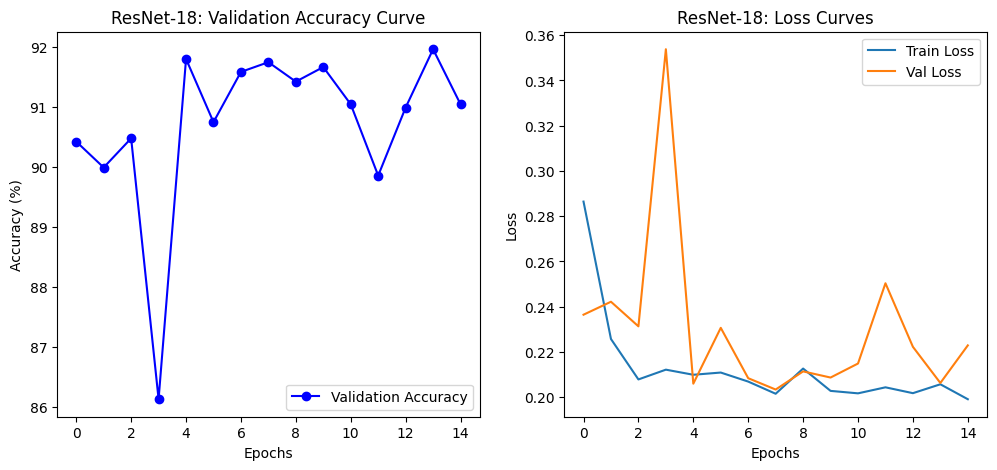

In [45]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_pt['v_acc'], label="Validation Accuracy", color='blue', marker='o')
plt.title("ResNet-18: Validation Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_pt['t_loss'], label="Train Loss")
plt.plot(history_pt['v_loss'], label="Val Loss")
plt.title("ResNet-18: Loss Curves")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
plt.show()

## 8.5. FINAL TEST EVALUATION


Classification Report (Fine-Tuned ResNet-18):
              precision    recall  f1-score   support

     Organic       0.89      0.97      0.93      2082
  Recyclable       0.95      0.85      0.90      1625

    accuracy                           0.92      3707
   macro avg       0.92      0.91      0.91      3707
weighted avg       0.92      0.92      0.92      3707



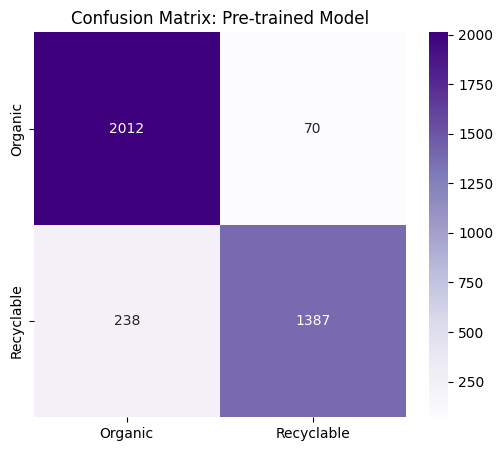

In [46]:
model_resnet.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in test_loader_pt:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Final Metrics
print("\nClassification Report (Fine-Tuned ResNet-18):")
print(classification_report(all_labels, all_preds, target_names=['Organic', 'Recyclable']))

# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=['Organic', 'Recyclable'], yticklabels=['Organic', 'Recyclable'])
plt.title("Confusion Matrix: Pre-trained Model")
plt.show()

## 8.6. Prediction using Pre-trained ResNet18

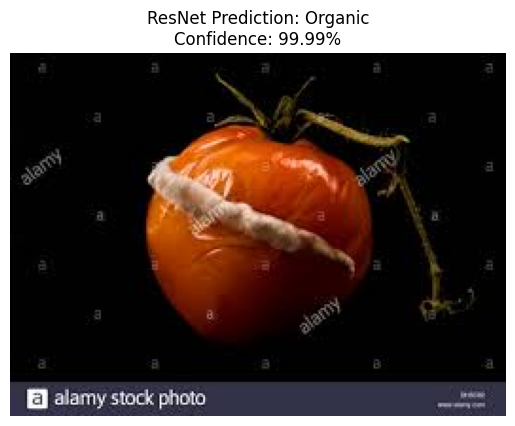

In [50]:
def predict_resnet_image(image_path, model):
    # 1. Define class names
    class_names = ['Organic', 'Recyclable']
    
    # 2. Handle Image Loading (URL vs Local Path)
    try:
        if image_path.startswith('http'):
            # If it's a URL, download it
            response = requests.get(image_path)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            # If it's a local file path
            img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # 3. Preprocess (Must use standard_transform)
    img_tensor = standard_transform(img).unsqueeze(0).to(device)
    
    # 4. Inference
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
        
    # 5. Display Result
    plt.imshow(img)
    plt.axis('off')
    label = class_names[predicted.item()]
    plt.title(f"ResNet Prediction: {label}\nConfidence: {confidence.item()*100:.2f}%")
    plt.show()


# Test with url link or saved image

test_url = '/kaggle/input/datasets/aaditighimire/wastemanagement/split_dataset/test/organic/organic_000119_photo.jpg'

predict_resnet_image(test_url, model_resnet)